<a href="https://colab.research.google.com/github/AnchalPandey29/Flipkart-Data-Analysis/blob/main/Flipkart_Mobile_Sales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

df = pd.read_csv("Flipkart_Mobiles.csv")

df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3114 entries, 0 to 3113
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           3114 non-null   object 
 1   Model           3114 non-null   object 
 2   Color           3114 non-null   object 
 3   Memory          3071 non-null   object 
 4   Storage         3075 non-null   object 
 5   Rating          2970 non-null   float64
 6   Selling Price   3114 non-null   int64  
 7   Original Price  3114 non-null   int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 194.8+ KB


In [2]:
df.isnull().sum()

,0
Brand,0
Model,0
Color,0
Memory,43
Storage,39
Rating,144
Selling Price,0
Original Price,0


In [3]:
df['Memory']= df['Memory'].fillna(df['Memory'].mode()[0])
df['Storage']= df['Storage'].fillna(df['Storage'].mode()[0])
df['Rating']= df['Rating'].fillna(df['Rating'].mean())

In [4]:
df.isnull().sum()

,0
Brand,0
Model,0
Color,0
Memory,0
Storage,0
Rating,0
Selling Price,0
Original Price,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3114 entries, 0 to 3113
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Brand           3114 non-null   object 
 1   Model           3114 non-null   object 
 2   Color           3114 non-null   object 
 3   Memory          3114 non-null   object 
 4   Storage         3114 non-null   object 
 5   Rating          3114 non-null   float64
 6   Selling Price   3114 non-null   int64  
 7   Original Price  3114 non-null   int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 194.8+ KB


In [6]:
df['Memory_raw']=df['Memory']

Extract Numeric Values

In [7]:
df['Memory_value'] = df['Memory_raw'].str.extract(r'(\d+)').astype(float)


Detect MB values

In [8]:
df['is_MB']=df['Memory_raw'].str.contains("MB",case=False)

converting everything to GB

In [9]:
df['Memory_GB']=df['Memory_value']
df.loc[df['is_MB'],'Memory_GB']=df['Memory_value']/1024

Validate

In [10]:
df[['Memory_raw','Memory_GB']].head(15)

,Memory_raw,Memory_GB
0,4 GB,4.0
1,4 GB,4.0
2,6 GB,6.0
3,6 GB,6.0
4,4 GB,4.0
5,6 GB,6.0
6,4 GB,4.0
7,3 GB,3.0
8,3 GB,3.0
9,3 GB,3.0


In [11]:
df

,Brand,Model,Color,Memory,Storage,Rating,Selling Price,Original Price,Memory_raw,Memory_value,is_MB,Memory_GB
0,OPPO,A53,Moonlight Black,4 GB,64 GB,4.5,11990,15990,4 GB,4.0,False,4.0
1,OPPO,A53,Mint Cream,4 GB,64 GB,4.5,11990,15990,4 GB,4.0,False,4.0
2,OPPO,A53,Moonlight Black,6 GB,128 GB,4.3,13990,17990,6 GB,6.0,False,6.0
3,OPPO,A53,Mint Cream,6 GB,128 GB,4.3,13990,17990,6 GB,6.0,False,6.0
4,OPPO,A53,Electric Black,4 GB,64 GB,4.5,11990,15990,4 GB,4.0,False,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...
3109,SAMSUNG,M52 5G,Blazing Black,6 GB,128 GB,4.3,25990,25990,6 GB,6.0,False,6.0
3110,SAMSUNG,M52 5G,Icy Blue,6 GB,128 GB,4.3,25489,28449,6 GB,6.0,False,6.0
3111,SAMSUNG,M52 5G,Icy Blue,8 GB,128 GB,4.3,27239,31489,8 GB,8.0,False,8.0
3112,SAMSUNG,M52 5G,Slate Black,8 GB,128 GB,4.2,22989,22989,8 GB,8.0,False,8.0


In [12]:
df

,Brand,Model,Color,Memory,Storage,Rating,Selling Price,Original Price,Memory_raw,Memory_value,is_MB,Memory_GB
0,OPPO,A53,Moonlight Black,4 GB,64 GB,4.5,11990,15990,4 GB,4.0,False,4.0
1,OPPO,A53,Mint Cream,4 GB,64 GB,4.5,11990,15990,4 GB,4.0,False,4.0
2,OPPO,A53,Moonlight Black,6 GB,128 GB,4.3,13990,17990,6 GB,6.0,False,6.0
3,OPPO,A53,Mint Cream,6 GB,128 GB,4.3,13990,17990,6 GB,6.0,False,6.0
4,OPPO,A53,Electric Black,4 GB,64 GB,4.5,11990,15990,4 GB,4.0,False,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...
3109,SAMSUNG,M52 5G,Blazing Black,6 GB,128 GB,4.3,25990,25990,6 GB,6.0,False,6.0
3110,SAMSUNG,M52 5G,Icy Blue,6 GB,128 GB,4.3,25489,28449,6 GB,6.0,False,6.0
3111,SAMSUNG,M52 5G,Icy Blue,8 GB,128 GB,4.3,27239,31489,8 GB,8.0,False,8.0
3112,SAMSUNG,M52 5G,Slate Black,8 GB,128 GB,4.2,22989,22989,8 GB,8.0,False,8.0


#Analysis

Average Price by RAM

In [13]:
df.groupby('Memory_GB')['Selling Price'].mean()

,Selling Price
Memory_GB,
0.001953,2299.500000
0.003906,1867.128205
0.007812,2936.357143
0.009766,2062.666667
0.015625,3353.687500
0.029297,3400.000000
0.031250,2842.857143
0.044922,2949.500000
0.062500,3481.266667


Best value RAM phone

In [14]:
df.sort_values(['Memory_GB','Selling Price'],ascending=[False,True]).head()

,Brand,Model,Color,Memory,Storage,Rating,Selling Price,Original Price,Memory_raw,Memory_value,is_MB,Memory_GB
1851,SAMSUNG,Galaxy M20,Ocean Blue,32 GB,64 GB,4.200000,9990,9990,32 GB,32.0,False,32.0
477,ASUS,ROG Phone 5 Ultimate,White,18 GB,512 GB,4.243098,79999,85999,18 GB,18.0,False,18.0
3035,ASUS,ROG 5s Pro,Phantom Black,18 GB,512 GB,4.243098,79999,85999,18 GB,18.0,False,18.0
466,ASUS,ROG Phone 5 Pro,Black,16 GB,512 GB,4.243098,69999,75999,16 GB,16.0,False,16.0
1998,SAMSUNG,Galaxy S21 Ultra,Phantom Black,16 GB,512 GB,4.300000,116999,139999,16 GB,16.0,False,16.0


In [15]:
df['Storage'].unique()

array(['64 GB', '128 GB', '32 GB', '256 GB', '16 GB', '8 GB', '4 GB',
       '512 GB', '16 MB', '128 MB', '2 MB', '4 MB', '48 MB', '8 MB',
       'Expandable Upto 32 GB', 'Expandable Upto 16 GB', '10 MB',
       '256 MB', '140 MB', '64 MB', '1 TB', '153 MB', '512 MB', '100 MB',
       '129 GB', '130 GB'], dtype=object)

Preserve Raw Data

In [16]:
df['Storage_raw'] = df['Storage']

Extracting Numeric Value

In [17]:
df['Storage_value'] = df['Storage_raw'].str.extract(r'(\d+)').astype(float)

Detect Storage Type

In [18]:
df['is_MB'] = df['Storage_raw'].str.contains('MB',case=False)
df['is_GB'] = df['Storage_raw'].str.contains('GB',case=False)
df['is_TB'] = df['Storage_raw'].str.contains('TB',case=False)
df['is_expandable'] = df['Storage_raw'].str.contains('Expandable',case=False)

Converting everything to GB

In [19]:
df['Storage_GB'] = df['Storage_value']
# mb to gb
df.loc[df['is_MB'],'Storage_GB'] = df['Storage_value']/1024
# tb to gb
df.loc[df['is_TB'],'Storage_GB'] = df['Storage_value']*1024

Separate Expandable Storage

In [20]:
df['Expandable_Storage_GB'] = None
df.loc[df['is_expandable'],'Expandable_Storage_GB'] = df['Storage_value']

Remove Expandable values from storage

In [21]:
df.loc[df['is_expandable'],'Storage_GB'] = None

In [22]:
df[['Storage_raw','Storage_GB','Expandable_Storage_GB']].head(10)

,Storage_raw,Storage_GB,Expandable_Storage_GB
0,64 GB,64.0,None
1,64 GB,64.0,None
2,128 GB,128.0,None
3,128 GB,128.0,None
4,64 GB,64.0,None
5,128 GB,128.0,None
6,64 GB,64.0,None
7,32 GB,32.0,None
8,32 GB,32.0,None
9,32 GB,32.0,None


Phone with Maximum Storage

In [23]:
df.sort_values(['Storage_GB'],ascending=False).head()

,Brand,Model,Color,Memory,Storage,Rating,Selling Price,Original Price,Memory_raw,Memory_value,is_MB,Memory_GB,Storage_raw,Storage_value,is_GB,is_TB,is_expandable,Storage_GB,Expandable_Storage_GB
1408,Apple,iPhone 13 Pro,Gold,6 GB,1 TB,4.243098,169900,169900,6 GB,6.0,False,6.0,1 TB,1.0,False,True,False,1024.0,None
1459,Apple,iPhone 13 Pro Max,Silver,6 GB,1 TB,4.243098,179900,179900,6 GB,6.0,False,6.0,1 TB,1.0,False,True,False,1024.0,None
1351,Apple,iPhone 13 Pro Max,Gold,6 GB,1 TB,4.243098,179900,179900,6 GB,6.0,False,6.0,1 TB,1.0,False,True,False,1024.0,None
3044,Apple,iPhone 13 Pro Max,Silver,4GB,1 TB,4.700000,179900,179900,4GB,4.0,False,4.0,1 TB,1.0,False,True,False,1024.0,None
3038,Apple,iPhone 13 Pro Max,Alpine Green,4GB,1 TB,4.700000,169900,169900,4GB,4.0,False,4.0,1 TB,1.0,False,True,False,1024.0,None


Best Value Phone

In [24]:
df.sort_values(['Storage_GB','Selling Price'],ascending=[False,True]).head()

,Brand,Model,Color,Memory,Storage,Rating,Selling Price,Original Price,Memory_raw,Memory_value,is_MB,Memory_GB,Storage_raw,Storage_value,is_GB,is_TB,is_expandable,Storage_GB,Expandable_Storage_GB
1713,SAMSUNG,Galaxy S10 Plus,Ceramic White,12 GB,1 TB,4.500000,117990,117990,12 GB,12.0,False,12.0,1 TB,1.0,False,True,False,1024.0,None
1393,Apple,iPhone 13 Pro,Graphite,6 GB,1 TB,4.243098,169900,169900,6 GB,6.0,False,6.0,1 TB,1.0,False,True,False,1024.0,None
1397,Apple,iPhone 13 Pro,Silver,6 GB,1 TB,4.243098,169900,169900,6 GB,6.0,False,6.0,1 TB,1.0,False,True,False,1024.0,None
1401,Apple,iPhone 13 Pro,Sierra Blue,6 GB,1 TB,4.243098,169900,169900,6 GB,6.0,False,6.0,1 TB,1.0,False,True,False,1024.0,None
1408,Apple,iPhone 13 Pro,Gold,6 GB,1 TB,4.243098,169900,169900,6 GB,6.0,False,6.0,1 TB,1.0,False,True,False,1024.0,None


Brand Analysis

In [25]:
df['Brand'].value_counts()

,count
Brand,
SAMSUNG,719
Apple,387
realme,327
OPPO,260
Nokia,213
Xiaomi,198
Infinix,151
GIONEE,129
vivo,124


Average Price of Brands

In [26]:
df.groupby('Brand')['Selling Price'].mean().sort_values()

,Selling Price
Brand,
GIONEE,7135.093023
Nokia,9428.657277
Lenovo,10083.842975
Infinix,11092.178808
Motorola,16357.466667
realme,16396.535168
POCO,16870.621622
Xiaomi,16941.909091
OPPO,18560.488462


<Axes: xlabel='Brand'>

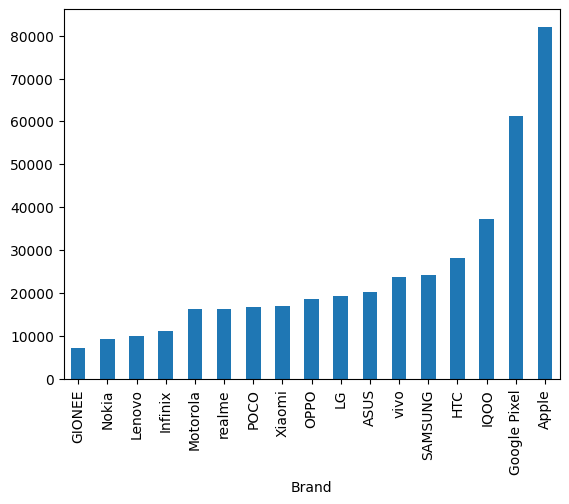

In [27]:
df.groupby('Brand')['Selling Price'].mean().sort_values().plot(kind='bar')

Price & Discount Analysis

In [28]:
df['discount'] = df['Original Price']-df['Selling Price']

In [29]:
df['Discount_Percentage'] = (df['discount']/df['Original Price'])*100

Top Discounted Phones

In [30]:
df.sort_values('Discount_Percentage',ascending=False).head()

,Brand,Model,Color,Memory,Storage,Rating,Selling Price,Original Price,Memory_raw,Memory_value,...,Memory_GB,Storage_raw,Storage_value,is_GB,is_TB,is_expandable,Storage_GB,Expandable_Storage_GB,discount,Discount_Percentage
803,GIONEE,Pioneer P3,White,512 MB,4 GB,3.6,2350,7996,512 MB,512.0,...,0.5,4 GB,4.0,True,False,False,4.0,None,5646,70.610305
879,GIONEE,Marathon M5 Plus,Polar Gold,3 GB,64 GB,4.1,8499,28099,3 GB,3.0,...,3.0,64 GB,64.0,True,False,False,64.0,None,19600,69.753372
443,ASUS,ROG,Black,8 GB,128 GB,4.3,26499,83999,8 GB,8.0,...,8.0,128 GB,128.0,True,False,False,128.0,None,57500,68.453196
2389,Motorola,Z2 Force,Super Black,6 GB,64 GB,4.1,14999,44999,6 GB,6.0,...,6.0,64 GB,64.0,True,False,False,64.0,None,30000,66.668148
1060,Nokia,8110,Black,512 MB,4 GB,3.7,3000,8400,512 MB,512.0,...,0.5,4 GB,4.0,True,False,False,4.0,None,5400,64.285714


Color Variation Analysis

In [31]:
df.groupby(['Model','Color'])['Selling Price'].mean().sort_values()

,,Selling Price
Model,Color,
Ta -1010/105,Black,1000.000000
GT 1200 R/I/M,Black,1099.000000
TA-1174 / TA-1299,Black,1149.000000
Guru 1200,Black,1150.000000
105,Black,1172.000000
...,...,...
Galaxy Z Fold3 5G,Phantom Black,155332.333333
iPhone 13 Pro Max,Sierra Blue,159900.000000
iPhone 13 Pro,Graphite,159900.000000


Correaltion Analysis

In [32]:
df[['Memory_GB','Rating','Selling Price','Original Price']].corr()

,Memory_GB,Rating,Selling Price,Original Price
Memory_GB,1.000000,0.326530,0.305311,0.337483
Rating,0.326530,1.000000,0.403680,0.403766
Selling Price,0.305311,0.403680,1.000000,0.986097
Original Price,0.337483,0.403766,0.986097,1.000000


In [33]:
df.head()

,Brand,Model,Color,Memory,Storage,Rating,Selling Price,Original Price,Memory_raw,Memory_value,...,Memory_GB,Storage_raw,Storage_value,is_GB,is_TB,is_expandable,Storage_GB,Expandable_Storage_GB,discount,Discount_Percentage
0,OPPO,A53,Moonlight Black,4 GB,64 GB,4.5,11990,15990,4 GB,4.0,...,4.0,64 GB,64.0,True,False,False,64.0,None,4000,25.015635
1,OPPO,A53,Mint Cream,4 GB,64 GB,4.5,11990,15990,4 GB,4.0,...,4.0,64 GB,64.0,True,False,False,64.0,None,4000,25.015635
2,OPPO,A53,Moonlight Black,6 GB,128 GB,4.3,13990,17990,6 GB,6.0,...,6.0,128 GB,128.0,True,False,False,128.0,None,4000,22.234575
3,OPPO,A53,Mint Cream,6 GB,128 GB,4.3,13990,17990,6 GB,6.0,...,6.0,128 GB,128.0,True,False,False,128.0,None,4000,22.234575
4,OPPO,A53,Electric Black,4 GB,64 GB,4.5,11990,15990,4 GB,4.0,...,4.0,64 GB,64.0,True,False,False,64.0,None,4000,25.015635


##Visualization
Matplotlib

Bar Plot - average
helps to understand which the stats points


used on discrete data and for comparing categories

In [34]:
import matplotlib.pyplot as plt


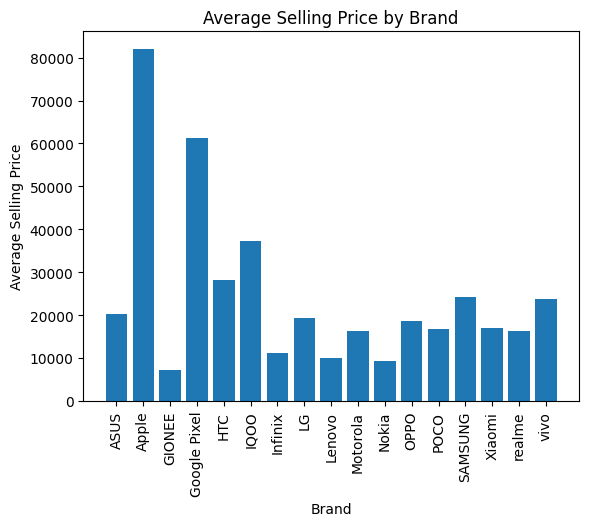

In [35]:
brand_price =df.groupby('Brand')['Selling Price'].mean()

plt.bar(brand_price.index,brand_price.values)
plt.xlabel('Brand')
plt.ylabel('Average Selling Price')
plt.title('Average Selling Price by Brand')
plt.xticks(rotation=90)
plt.show()

##Line Plot
Trends over time

ordered/ continouous data

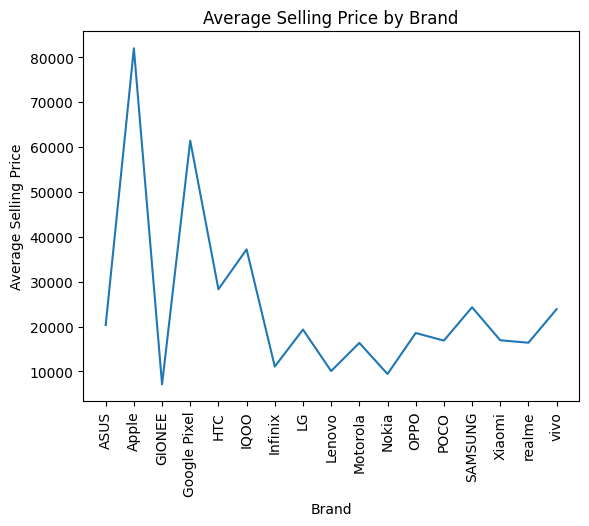

In [36]:
plt.plot(brand_price.index,brand_price.values)
plt.xlabel('Brand')
plt.ylabel('Average Selling Price')
plt.title('Average Selling Price by Brand')
plt.xticks(rotation=90)
plt.show()

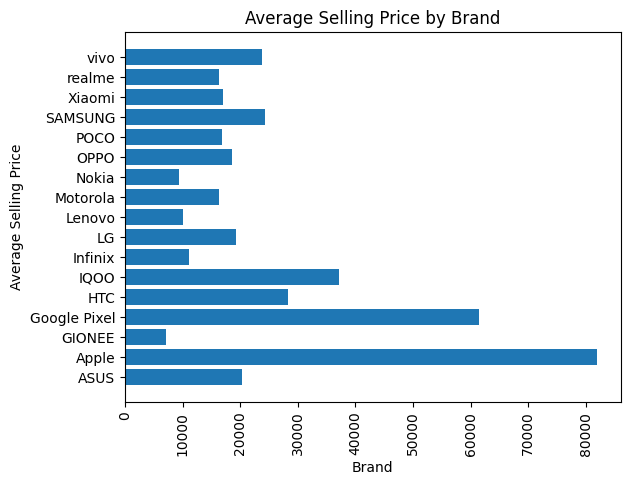

In [37]:
plt.barh(brand_price.index,brand_price.values)
plt.xlabel('Brand')
plt.ylabel('Average Selling Price')
plt.title('Average Selling Price by Brand')
plt.xticks(rotation=90)
plt.show()

##Histogram
distribution of numeric data


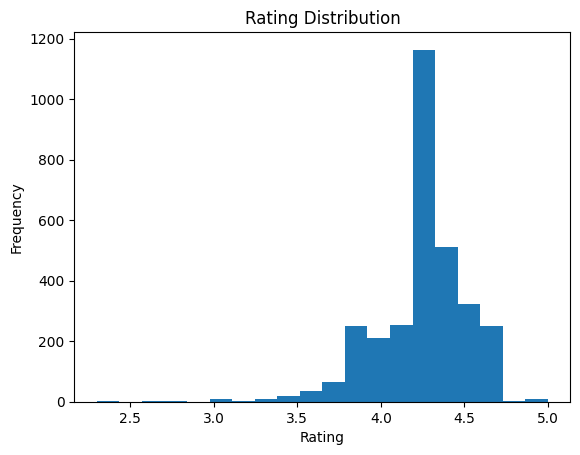

In [38]:
import matplotlib.pyplot as plt
plt.hist(df['Rating'], bins=20)
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.title('Rating Distribution')
plt.show()

#Scatter Plot
relationship between two variables/fields

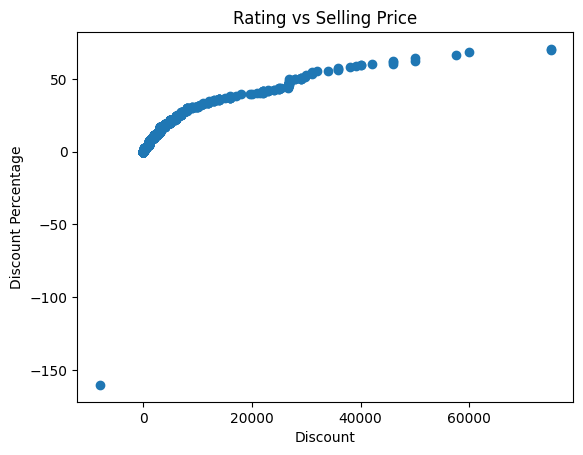

In [39]:
discount_value = df['discount'].sort_values()
discount_percent = df['Discount_Percentage'].sort_values()

plt.scatter(discount_value,discount_percent)
plt.xlabel('Discount')
plt.ylabel('Discount Percentage')
plt.title('Rating vs Selling Price')
plt.show()

#Boxplot
used to detect outliers and statistical summary of data

/tmp/ipykernel_528/4126494173.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([discount_value,selling],labels=['Discount','Selling Price'])


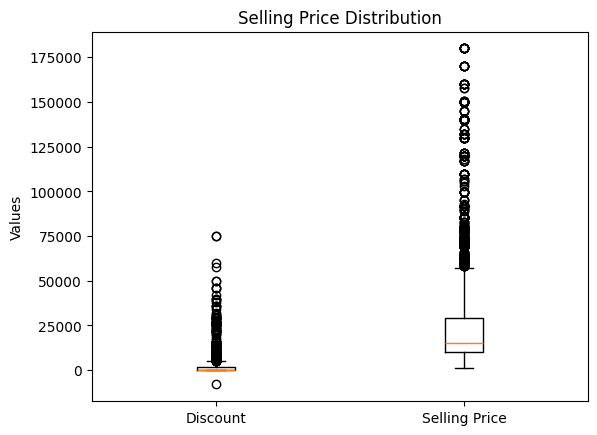

In [40]:
selling = df['Selling Price']



plt.boxplot([discount_value,selling],labels=['Discount','Selling Price'])
plt.title('Selling Price Distribution')
# plt.xlabel('Selling Price')
plt.ylabel('Values')
plt.show()

#KDE
kernel density estimator

used to find the density of data

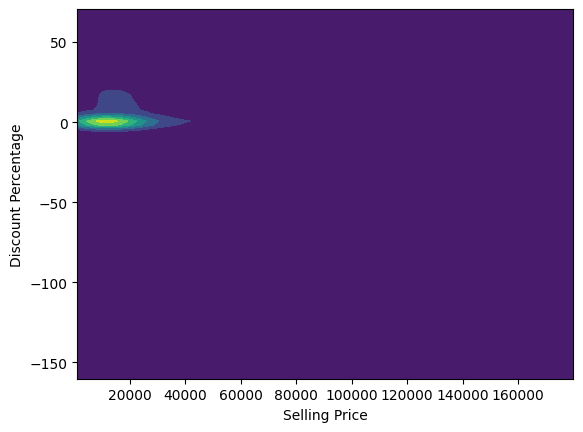

In [41]:
from scipy.stats import gaussian_kde
import numpy as np

kde = gaussian_kde(np.vstack([df['Selling Price'], df['Discount_Percentage']]))

x, y = np.mgrid[
    df['Selling Price'].min():df['Selling Price'].max():100j,
    df['Discount_Percentage'].min():df['Discount_Percentage'].max():100j
]

z = kde([x.ravel(),y.ravel()]).reshape(x.shape)

plt.contourf(x,y,z)
plt.xlabel('Selling Price')
plt.ylabel('Discount Percentage')
plt.show()

Voilin Plot

kde+box


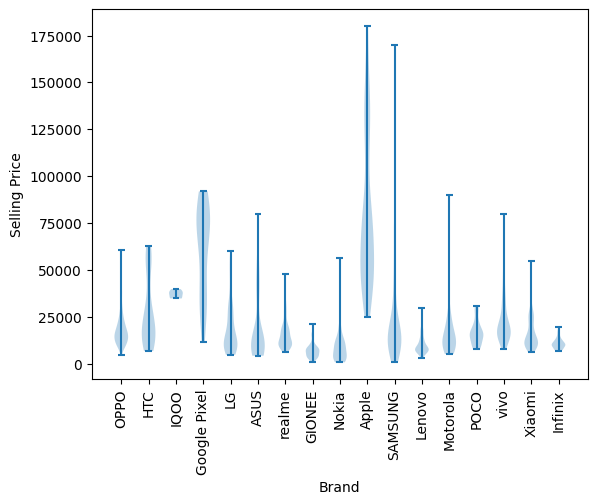

In [42]:
brand = df['Brand'].unique()
price_data = [df[df['Brand']==b]['Selling Price'] for b in brand]

plt.violinplot(price_data)
plt.xticks(range(1,len(brand)+1),brand,rotation=90)
plt.xlabel('Brand')
plt.ylabel('Selling Price')
plt.show()


PieChart

used to show the fraction/proportion of whole

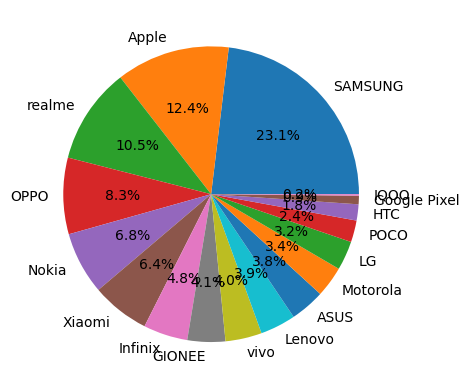

In [43]:
brand_count = df['Brand'].value_counts()

plt.pie(brand_count.values,labels=brand_count.index,autopct='%1.1f%%')
plt.show()

SubPlot

for making multiple dashboard style plots

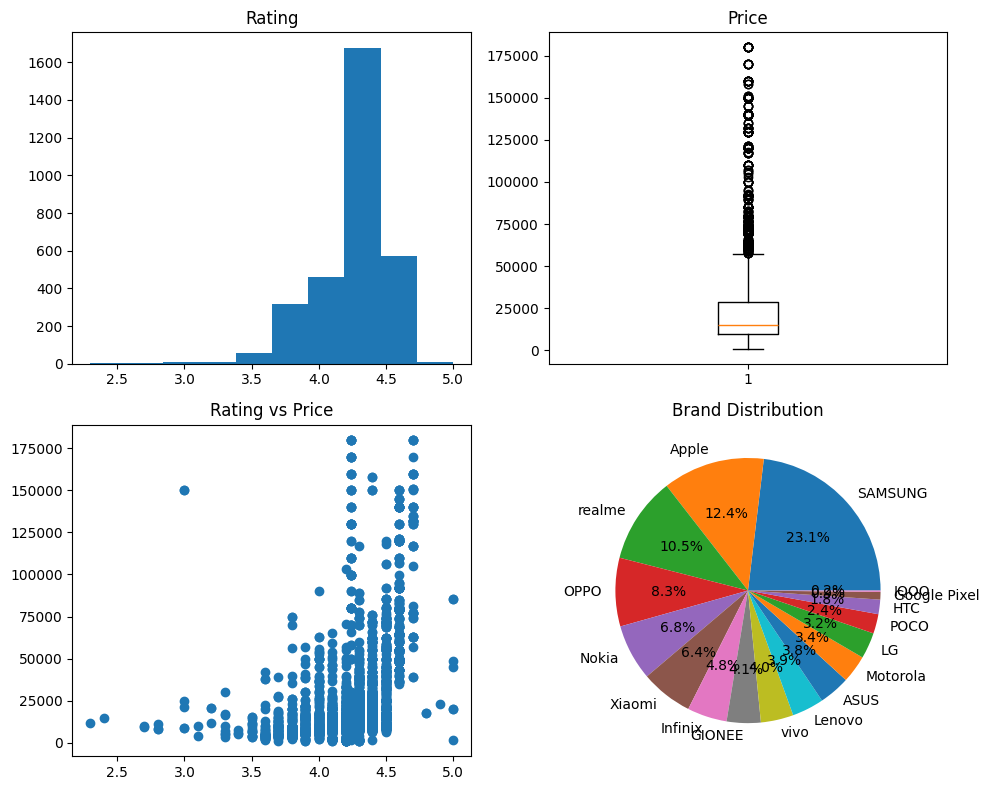

In [44]:
plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.hist(df['Rating'])
plt.title("Rating")

plt.subplot(2,2,2)
plt.boxplot(df['Selling Price'])
plt.title("Price")

plt.subplot(2,2,3)
plt.scatter(df['Rating'],df['Selling Price'])
plt.title("Rating vs Price")

plt.subplot(2,2,4)
plt.pie(brand_count.values,labels=brand_count.index,autopct='%1.1f%%')
plt.title("Brand Distribution")

plt.tight_layout()
plt.show()

Stem Plot

used to show  discrete numeric values

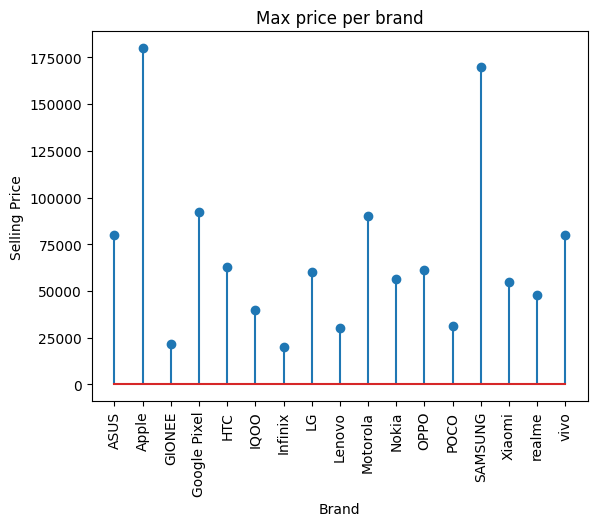

In [45]:
brand_max_price = df.groupby('Brand')['Selling Price'].max()

plt.stem(brand_max_price)
plt.xlabel('Brand')
plt.ylabel('Selling Price')
plt.xticks(range(len(brand_max_price)),brand_max_price.index,rotation=90)
plt.title('Max price per brand')
plt.show()

Lolipop

used to show ranking

Brand
ASUS            4.092387
Apple           4.525282
GIONEE          3.857257
Google Pixel    4.506897
HTC             3.969091
IQOO            4.400000
Infinix         4.276821
LG              3.984274
Lenovo          3.977216
Motorola        4.144630
Nokia           4.029002
OPPO            4.296492
POCO            4.385718
SAMSUNG         4.208726
Xiaomi          4.302821
realme          4.383412
vivo            4.373748
Name: Rating, dtype: float64


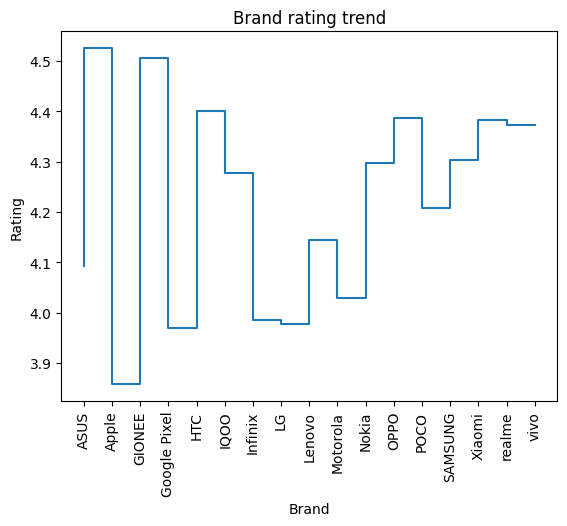

In [46]:
brand_rating = df.groupby('Brand')['Rating'].mean()

print(brand_rating)

plt.step(brand_rating.index,brand_rating.values)
plt.xlabel("Brand")
plt.ylabel("Rating")
plt.xticks(rotation=90)
plt.title("Brand rating trend")
plt.show()

Bubble

used for three variables

/usr/local/lib/python3.12/dist-packages/matplotlib/collections.py:1008: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


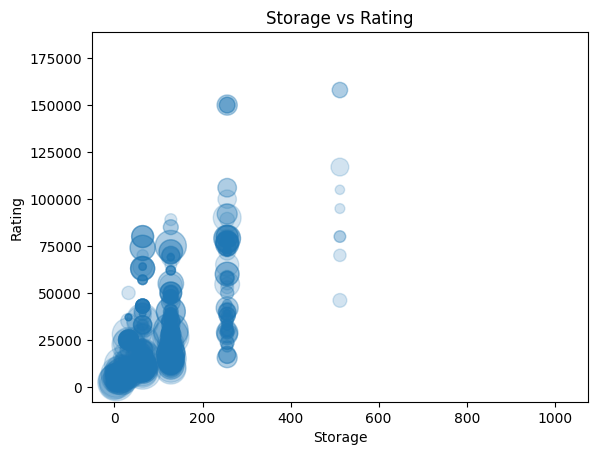

In [47]:
plt.scatter(df['Storage_GB'],df['Selling Price'],s=df['Discount_Percentage']*10,alpha=0.2)
plt.xlabel('Storage')
plt.ylabel('Rating')
plt.title('Storage vs Rating')
plt.show()

In [48]:
df.shape

(3114, 21)

Area Plot

trend + magnitude

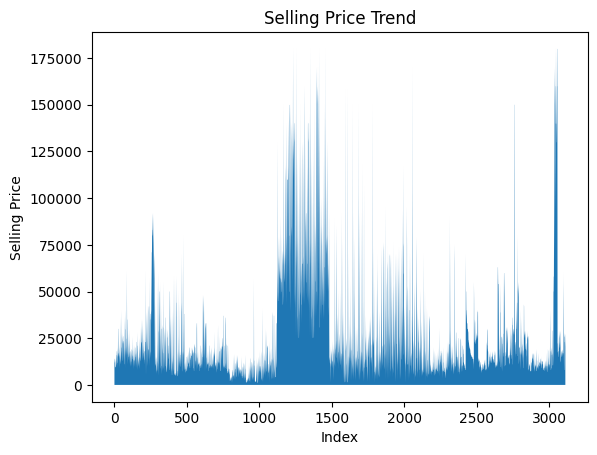

In [49]:
plt.fill_between(df.index, df['Selling Price'])
plt.xlabel("Index")
plt.ylabel("Selling Price")
plt.title("Selling Price Trend")
plt.show()

Count

count plot shows the no of occurences of each category

In [50]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

df = sns.load_dataset('tips')


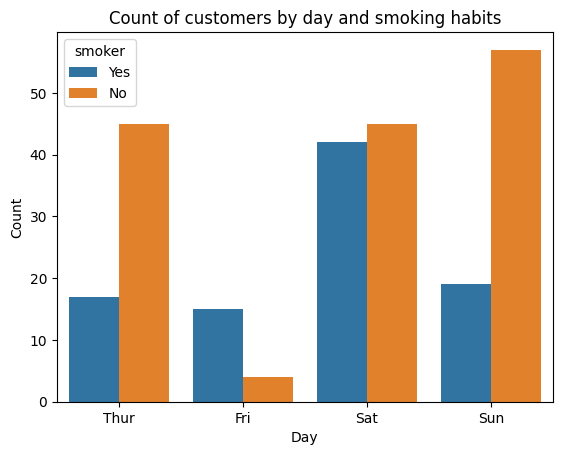

In [51]:
sns.countplot(x='day',data=df,hue='smoker',order=["Thur","Fri","Sat","Sun"])
plt.title("Count of customers by day and smoking habits")
plt.xlabel("Day")
plt.ylabel("Count")
plt.show()

Bar Plot

shows the mean comparison of each category

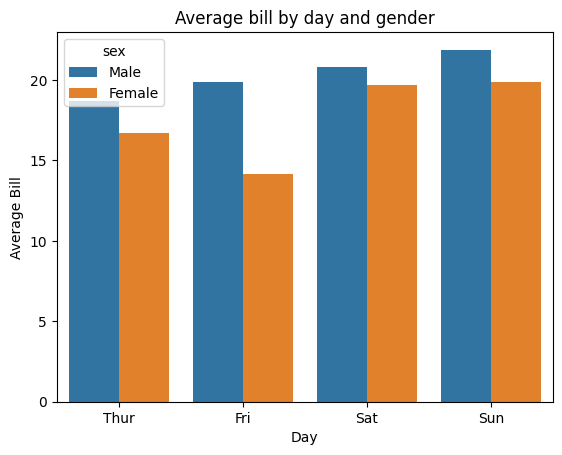

In [52]:
sns.barplot(x='day',y='total_bill',hue="sex",data=df,errorbar=None)
plt.title("Average bill by day and gender")
plt.xlabel("Day")
plt.ylabel("Average Bill")
plt.show()

KDE

To show the density of data, concentrated area

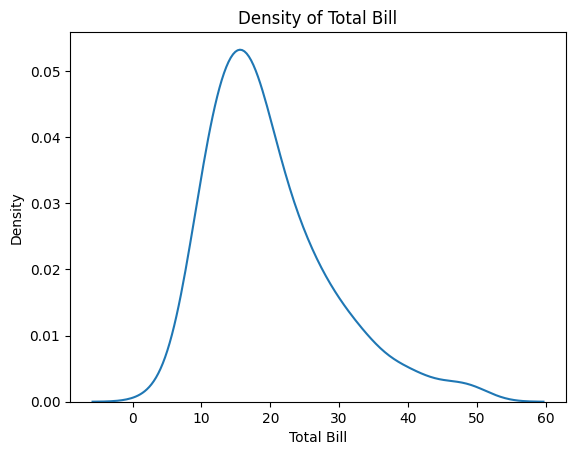

In [54]:
sns.kdeplot(df['total_bill'])
plt.title("Density of Total Bill")
plt.xlabel("Total Bill")
plt.ylabel("Density")
plt.show()

In [ ]:
## Conclusion

# This project involved a comprehensive analysis of mobile phone data, starting from initial data loading and handling of missing values. Key preprocessing steps included extracting and standardizing 'Memory' and 'Storage' capacities into a uniform 'GB' unit, while also separating expandable storage information.

# Our analysis revealed interesting insights into phone specifications and pricing:

# *   **Memory (RAM)**: We explored the average selling price across different RAM configurations, identifying trends and potential 'best value' options that offer higher RAM at competitive prices.
# *   **Storage**: Similar to RAM, storage analysis helped identify phones with the largest storage capacities and those offering the best value in terms of storage per price.
# *   **Brand Performance**: A detailed brand analysis showcased the market presence of various brands and their average selling prices, providing a clear picture of brand positioning.
# *   **Price and Discount**: By calculating 'discount' and 'Discount_Percentage', we were able to pinpoint phones with the most significant price reductions, indicating potential deals for consumers.
# *   **Correlation**: The correlation analysis highlighted relationships between key numerical features like Memory, Rating, Selling Price, and Original Price, suggesting that higher memory and ratings generally correlate with higher prices.

# Throughout the project, a variety of visualization techniques, including bar plots, line plots, histograms, scatter plots, box plots, KDE plots, violin plots, pie charts, subplots, stem plots, lollipop plots, bubble plots, area plots, count plots, and bar plots (using Seaborn), were employed to effectively illustrate data distributions, relationships, and trends. These visualizations were instrumental in making complex data patterns easily interpretable and in drawing meaningful conclusions from the dataset.

# Overall, this analysis provides a foundational understanding of the mobile phone market based on the provided dataset, offering insights valuable for both consumers seeking optimal deals and businesses looking to understand market dynamics.